# <center>Lecture 2: Logit, multivariate extreme value, and max-stability</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 2** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering sections 2.1 (the logit model and the Gumbel distribution), 2.2 (multivariate extreme value generalizations), 2.3 (the nested logit model), 2.4 (the three families of max-stable distributions) and 2.5 (continuous logit). It runs the book's code listings `2-01`, `2-02` and `2-03` and extends them. Slide deck: folders `ch2/ch2.1`–`ch2/ch2.5`.

**One reordering.** The book presents the three max-stable families in section 2.4, after the nested logit. Here they come immediately after section 2.1, because max-stability is *why* the Gumbel is the distribution of the logit, and the argument is more convincing when the Fisher–Tippett–Gnedenko theorem is in hand before the generalizations start. The mathematical content is the book's; only the order differs.

### Learning objectives

* Why the Gumbel: max-stability, and the sense in which it is the *only* choice with unbounded support.
* The Fisher–Tippett–Gnedenko theorem and the three max-stable families, verified by simulation.
* The multivariate extreme value (MEV) class as a factor model built from i.i.d. Gumbel factors; the dependence function $h$, and $G(U) = \log h(e^U) + \gamma$.
* The nested logit: its Gumbel decomposition, its closed-form $G$, $\pi$, $G^\ast$ and $\pi^{-1}$, and the substitution patterns it buys.
* Independence of irrelevant alternatives, what it costs, and how nesting relaxes it.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 2**.
* McFadden (1978). "Modelling the Choice of Residential Location", in Karlqvist et al. (eds.), *Spatial Interaction Theory and Planning Models*. The MEV (there "GEV") class.
* Ben-Akiva (1973). *Structure of Passenger Travel Demand Models*. PhD thesis, MIT. The nested logit.
* de Haan and Ferreira (2006). *Extreme Value Theory: An Introduction*. Springer. Fisher–Tippett–Gnedenko is theorem 1.1.3 there.
* Luce (1959). *Individual Choice Behavior*. The IIA axiomatization.
* Kanter (1975). "Stable Densities Under Change of Scale and Total Variation Inequalities". *Annals of Probability*. The positive-stable sampler used in section 4.
* Galichon and Salanié (2022). "Cupid's Invisible Hand". *Review of Economic Studies*. Entropy of choice, specialized to the nested logit here.
* Previous lecture: `dc01_random-utility-welfare-and-inversion` — $G$, $\pi$, $G^\ast$, and the inversion theorem used throughout.

## Motivation: why this distribution?

Lecture 1 built $G$, $\pi$ and $G^\ast$ for an arbitrary distribution $\mathcal{P}$ of utility shocks, and closed by inverting the travel-mode shares twice — once under a Gumbel assumption, once under a Gaussian one — and finding that the two agreed on the ranking of modes and disagreed on the magnitudes. **The distribution of heterogeneity is not innocuous, and it is not observed.** This lecture asks what can be said in its defence.

The answer is max-stability. The Gumbel is the unique distribution, up to location and scale, that is stable under taking maxima and has unbounded support — and since a discrete choice model is *entirely* a statement about a maximum, that is a real argument, not a convenience. It is also what buys the closed forms: $G$ becomes a log-sum-exp, $\pi$ becomes a softmax, $G^\ast$ becomes the Gibbs entropy.

The price is **independence of irrelevant alternatives**. In the logit the odds of $y$ against $y'$ do not depend on what else is available, which is wrong whenever two options are close substitutes. So the rest of the chapter loosens the independence of the shocks while keeping max-stability of each margin: the multivariate extreme value class, built as a factor model out of i.i.d. Gumbel factors, and its most-used member, the nested logit.

**The dual object.** It is the same as in lecture 1 — the entropy of choice $G^\ast$, dual to $G$ — but the nest structure now shows up *inside* it. We will see that the nested logit's entropy splits into a within-nest term weighted by $\lambda_x$ and a between-nest term weighted by $1-\lambda_x$, and that the inverse market share map is a two-level log-odds. Reading $\lambda_x$ as a weight on the two levels of entropy is what makes the correlation parameter interpretable.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

rng = np.random.default_rng(2)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)
gamma_euler = np.euler_gamma
print('Euler-Mascheroni constant gamma =', round(gamma_euler, 6))

Euler-Mascheroni constant gamma = 0.577216


## 1. The Gumbel distribution and max-stability

*(Book, section 2.1.)*

The **standard Gumbel** $\mathcal{G}$ has c.d.f.
$$F_{\mathcal G}(u) = \exp(-\exp(-u)),\qquad u\in\mathbb{R},$$
mean $\gamma \approx 0.5772$ (the Euler–Mascheroni constant) and variance $\pi^2/6$. The **centered Gumbel** shifts it to mean zero: $F(u) = \exp(-\exp(-u-\gamma))$. Lecture 1 used the centered version; this lecture uses the standard one and carries the $\gamma$ explicitly, which is the book's convention in this chapter.

A distribution is **max-stable** if the maximum of $Y$ i.i.d. copies is, after an affine rescaling, the same distribution:
$$\max_{y\in[Y]}\varepsilon_y \;=_D\; a_Y\,\epsilon + b_Y.$$
For the Gumbel this is immediate: $\Pr(\max_y \varepsilon_y \le u) = \exp(-Y e^{-u}) = F_{\mathcal G}(u - \log Y)$, so $a_Y = 1$ and $b_Y = \log Y$.

> **Proposition (book 2.1).** The standard Gumbel is, up to a location–scale transform, the only max-stable distribution whose support is unbounded above and below.

That is the whole case for the logit. Now the version with utilities attached:

> **Proposition (book 2.2).** If the $\varepsilon_y$ are i.i.d. standard Gumbel, then
> $$\max_{y\in[Y]}\{U_y+\varepsilon_y\} = \log\Big(\sum_y e^{U_y}\Big) + \epsilon,\qquad \epsilon\sim\mathcal{G}.$$

> **Theorem (book 2.3).** Hence $G(U) = \log\big(\sum_y e^{U_y}\big) + \gamma$ and $\pi_y(U) = e^{U_y}/\sum_z e^{U_z}$.

Note the $\gamma$: with *standard* Gumbel shocks the welfare function carries $+\gamma$, which the centered convention of lecture 1 absorbs. Getting this wrong shifts every welfare number by $0.577$ while leaving every share untouched — a bug that is invisible in the shares and fatal in the counterfactuals.

In [2]:
def cdf_gumbel(u):
    return np.exp(-np.exp(-u))


I_draw = 400_000 if not FAST_MODE else 200_000
Y_test = 7

# --- max-stability: max of Y i.i.d. Gumbels, shifted by log Y, is Gumbel
eps = rng.gumbel(size=(I_draw, Y_test))
M = eps.max(axis=1) - np.log(Y_test)
ks = stats.kstest(M, cdf_gumbel)
print(f'max-stability   : KS statistic = {ks.statistic:.5f}, p = {ks.pvalue:.3f}')

# --- proposition 2.2: max_y {U_y + eps_y} - log sum exp U_y is Gumbel, for U =/= 0
U_y = np.array([0.0, 0.9, 0.7, 0.3, -0.5, 1.2, -0.2])
M2 = (U_y[None, :] + eps).max(axis=1) - np.logaddexp.reduce(U_y)
ks2 = stats.kstest(M2, cdf_gumbel)
print(f'proposition 2.2 : KS statistic = {ks2.statistic:.5f}, p = {ks2.pvalue:.3f}')

# --- theorem 2.3: the closed forms for G and pi
G_cf = np.logaddexp.reduce(U_y) + gamma_euler
G_sim = (U_y[None, :] + eps).max(axis=1).mean()
pi_cf = np.exp(U_y - np.logaddexp.reduce(U_y))
pi_sim = ((U_y[None, :] + eps) == (U_y[None, :] + eps).max(axis=1)[:, None]).mean(axis=0)

print(f'\nG  closed form / simulated : {G_cf:.4f} / {G_sim:.4f}   '
      f'(simulation s.e. = {(U_y+eps).max(axis=1).std()/np.sqrt(I_draw):.4f})')
print('pi closed form :', pi_cf)
print('pi simulated   :', pi_sim)
print('discrepancy in simulation s.e. :',
      np.abs(pi_sim - pi_cf) / np.sqrt(pi_cf * (1 - pi_cf) / I_draw))
assert ks.pvalue > 0.01 and ks2.pvalue > 0.01

max-stability   : KS statistic = 0.00152, p = 0.747
proposition 2.2 : KS statistic = 0.00123, p = 0.921

G  closed form / simulated : 3.0255 / 3.0238   (simulation s.e. = 0.0029)
pi closed form : [0.0864 0.2126 0.1741 0.1167 0.0524 0.287  0.0708]
pi simulated   : [0.0859 0.2138 0.1747 0.1166 0.0533 0.2855 0.0702]
discrepancy in simulation s.e. : [0.8847 1.344  0.7718 0.1227 1.6672 1.4572 1.0409]


Both Kolmogorov–Smirnov tests pass comfortably, so the two propositions survive contact with $2\times10^5$ draws, and the closed forms for $G$ and $\pi$ match simulation within Monte Carlo error. Note that the KS test is the right instrument here: max-stability is a claim about a *whole distribution*, not about its first two moments, and matching means and variances would not have distinguished the Gumbel from several competitors.

### Independence of irrelevant alternatives

The logit share formula implies
$$\frac{\pi_y(U)}{\pi_{y'}(U)} = e^{U_y - U_{y'}},$$
which depends on $y$ and $y'$ alone — not on what else is on the menu. This is **IIA**, and by an exercise in the book it *characterizes* the logit among random utility models. It is also its principal defect, and the reason for everything that follows.

In [3]:
# the red-bus/blue-bus problem: adding a near-duplicate steals share proportionally
U_two = np.array([0.0, 0.0])                       # car, red bus: 50/50
U_three = np.array([0.0, 0.0, 0.0])                # car, red bus, blue bus

p2 = np.exp(U_two) / np.exp(U_two).sum()
p3 = np.exp(U_three) / np.exp(U_three).sum()

print('two options   (car, red bus)            :', p2)
print('three options (car, red bus, blue bus)  :', p3)
print('\nodds of car against red bus, before :', round(p2[0] / p2[1], 4))
print('odds of car against red bus, after  :', round(p3[0] / p3[1], 4), ' <- unchanged: IIA')
print('\nbut a blue bus is a near-perfect substitute for a red bus, so car should have')
print('kept its 1/2 share and the two buses should have split the other half.')

two options   (car, red bus)            : [0.5 0.5]
three options (car, red bus, blue bus)  : [0.3333 0.3333 0.3333]

odds of car against red bus, before : 1.0
odds of car against red bus, after  : 1.0  <- unchanged: IIA

but a blue bus is a near-perfect substitute for a red bus, so car should have
kept its 1/2 share and the two buses should have split the other half.


Adding a bus painted a different colour takes a third of the car's share. No behavioural story supports that, and no amount of data will fix it, because the defect is in the distribution of $\varepsilon$, not in $U$. Sections 3 and 4 fix it by correlating the shocks.

## 2. The three max-stable families

*(Book, section 2.4, brought forward. Runs listing `2-03`.)*

Max-stability is a strong restriction, and the Fisher–Tippett–Gnedenko theorem says exactly how strong:

> **Theorem (Fisher–Tippett–Gnedenko; book theorem 2.5).** If the rescaled maximum $(\max_{i\le I}\varepsilon_i - b_I)/a_I$ of i.i.d. draws converges in distribution to a nondegenerate limit, that limit is, up to location and scale, one of three:
> * **Type I, Gumbel**: $\exp(-e^{-u})$, unbounded above and below;
> * **Type II, Fréchet**: $\exp(-u^{-\alpha})$ on $u>0$, bounded below, heavy upper tail;
> * **Type III, Weibull**: $\exp(-(-u)^{\alpha})$ on $u<0$, bounded above.

Only the Gumbel has unbounded support, which is proposition 2.1 above. Listing `2-03` illustrates the three cases by simulation: maxima of exponentials converge to Type I, maxima of Paretos to Type II, maxima of uniforms to Type III. We keep the book's three experiments and its rescalings, and add what the listing does not do — a **Kolmogorov–Smirnov test** of each limit law, so that "the empirical c.d.f. looks like a straight line" becomes a number.

In [4]:
def max_of(sampler, R, I, block=200):
    '''Maxima of I i.i.d. draws, repeated R times, in memory-safe blocks.'''
    out = np.empty(R)
    for s in range(0, R, block):
        n = min(block, R - s)
        out[s:s + n] = sampler((n, I)).max(axis=1)
    return out


R = 4000 if not FAST_MODE else 2000
I = 100_000 if not FAST_MODE else 40_000
lambda_exp, alpha_pareto = 0.8, 0.6

# Type I: maxima of exponentials, rescaled by  M/lambda - log I
M1 = max_of(lambda sz: rng.exponential(scale=lambda_exp, size=sz), R, I)
M1 = M1 / lambda_exp - np.log(I)
# Type II: maxima of Paretos, rescaled by  M / I^(1/alpha)
M2 = max_of(lambda sz: rng.pareto(a=alpha_pareto, size=sz), R, I)
M2 = M2 / I ** (1 / alpha_pareto)
# Type III: maxima of uniforms, rescaled by  I*M - I
M3 = max_of(lambda sz: rng.uniform(size=sz), R, I)
M3 = I * M3 - I

limits = {
    'Type I  Gumbel  (from exponentials)': (M1, lambda u: np.exp(-np.exp(-u))),
    'Type II Frechet (from Paretos)     ': (M2, lambda u: np.exp(-np.maximum(u, 1e-300) ** (-alpha_pareto))),
    'Type III Weibull (from uniforms)   ': (M3, lambda u: np.exp(-np.maximum(-u, 0.0))),
}
for name, (M, F) in limits.items():
    k = stats.kstest(M, F)
    print(f'{name}: KS = {k.statistic:.4f}, p = {k.pvalue:.3f}')

Type I  Gumbel  (from exponentials): KS = 0.0139, p = 0.832
Type II Frechet (from Paretos)     : KS = 0.0144, p = 0.799
Type III Weibull (from uniforms)   : KS = 0.0163, p = 0.655


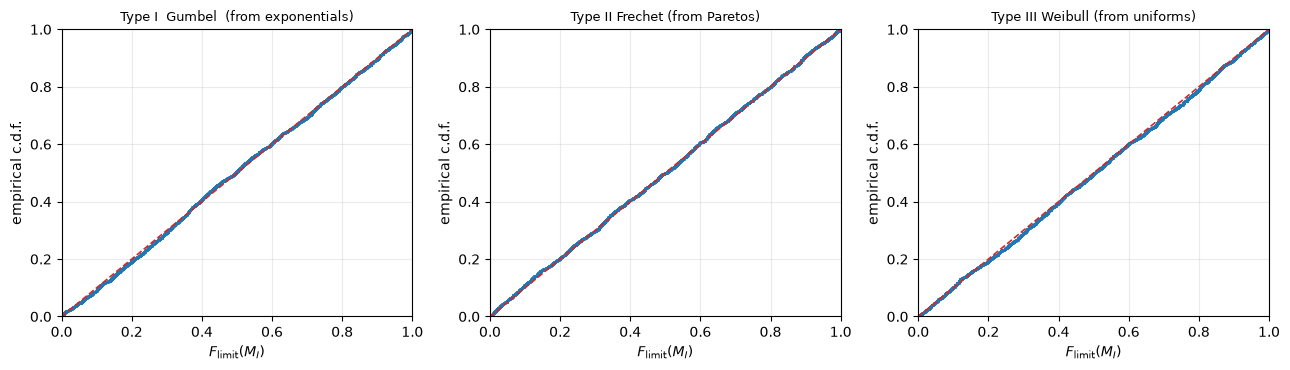

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for a, (name, (M, F)) in zip(ax, limits.items()):
    Ut = np.sort(F(M))                                   # probability integral transform
    a.plot(Ut, np.arange(1, len(Ut) + 1) / len(Ut), '.', ms=2.5, color='C0')
    a.plot([0, 1], [0, 1], '--', color='C3', lw=1.2)
    a.set_xlabel('$F_{\\mathrm{limit}}(M_I)$'); a.set_ylabel('empirical c.d.f.')
    a.set_title(name.strip(), fontsize=9.5)
    a.set_xlim(0, 1); a.set_ylim(0, 1); a.grid(alpha=.25)
plt.tight_layout(); plt.show()

If the rescaled maximum really follows the limit law, then pushing it through that law's c.d.f. gives a uniform, and the empirical c.d.f. of the result is the 45-degree line. All three panels sit on the diagonal and all three KS tests pass. The three families are not a taxonomy imposed for tidiness: they are what maxima of *anything* converge to.

For discrete choice this settles the question raised at the top. If we want a model in which the shock distribution is preserved under the operation the model is made of — taking a maximum — and we want it defined on the whole real line, we have exactly one candidate.

## 3. Multivariate extreme value distributions

*(Book, section 2.2. Runs listing `2-01`.)*

Independence across alternatives is the part of the logit worth giving up. The MEV class does so while keeping every margin Gumbel, and the construction is a **factor model**.

Take $X$ i.i.d. standard Gumbel factors $\eta_x$. For any weights with $\sum_x e^{U_{xy}} = 1$, proposition 2.2 says
$$\varepsilon_y = \max_{x\in[X]}\{U_{xy}+\eta_x\}\ \sim\ \mathcal{G}$$
for every $y$ — each margin is standard Gumbel, but two alternatives that load on the same factors are correlated. Loading on identical factors gives $\varepsilon_y=\varepsilon_{y'}$; loading on disjoint factors gives independence; everything in between is available. The analogy is exact: correlated Gaussians are built from i.i.d. normal factors by *addition*, because the Gaussian is stable under addition; correlated Gumbels are built from i.i.d. Gumbel factors by *maximization*, because the Gumbel is stable under maximization.

> **Definition (book 2.1).** $\varepsilon$ is in the **multivariate extreme value class** if $F_\varepsilon(v) = \exp(-h(e^{-v}))$ for some $h:\mathbb{R}_+^Y\to\mathbb{R}_+$ positively homogeneous of degree 1. The function $h$ is the **dependence function**.

> **Proposition (book 2.4).** Then $\max_y\{U_y+\varepsilon_y\} = \log h(e^U) + \epsilon$ with $\epsilon\sim\mathcal{G}$, so
> $$G(U) = \log h(e^U) + \gamma,\qquad \pi_y(U) = \frac{\partial_y h(e^U)\,e^{U_y}}{h(e^U)}.$$

The i.i.d. Gumbel case is $h(b)=\sum_y b_y$: **additive separability of $h$ is exactly independence** of the corresponding shocks, and this is the sense in which $h$ measures dependence. Proposition 2.5 goes further and gives the **Pickands representation** $h(b)=\mathbb{E}[\max_y\{b_yZ_y\}]$ — every dependence function is the support function of a random vector.

Listing `2-01` builds the factor model with a Zipf-like loading. Setting
$$U_x = \log\frac{x^{-\lambda}}{\sum_x x^{-\lambda}},\qquad U'_x = \log\frac{(1+X-x)^{-\lambda}}{\sum_x x^{-\lambda}},$$
so that $\varepsilon$ loads mostly on the low-indexed factors and $\varepsilon'$ mostly on the high-indexed ones, the pair $(\varepsilon,\varepsilon')$ is the shock vector of a single-nest binomial nested logit, and its correlation tends to $1-\lambda^2$ as $X\to\infty$.

In [6]:
def mev_factor_pair(X, lam, R, gen, block=25):
    '''Listing 2-01: two Gumbel variables built from X shared i.i.d. Gumbel factors.'''
    w = np.arange(1, X + 1, dtype=float) ** (-lam)
    denom = w.sum()
    U_x = np.log(w / denom)                 # loads on small x
    Up_x = np.log(w[::-1] / denom)          # loads on large x
    eps = np.empty(R); epsp = np.empty(R)
    for s in range(0, R, block):
        n = min(block, R - s)
        eta = gen.gumbel(size=(n, X))       # the shared factors
        eps[s:s + n] = (U_x[None, :] + eta).max(axis=1)
        epsp[s:s + n] = (Up_x[None, :] + eta).max(axis=1)
    return eps, epsp


lam = 0.8
R_mev = 1000 if not FAST_MODE else 600
X_grid = [2_000, 20_000, 200_000] if not FAST_MODE else [2_000, 20_000, 100_000]

print(f'target correlation 1 - lambda^2 = {1 - lam**2:.4f}   (lambda = {lam})\n')
print(f"{'X':>8} {'corr':>9} {'s.e.':>8}   margins are standard Gumbel? (KS p-values)")
for X in X_grid:
    e, ep = mev_factor_pair(X, lam, R_mev, rng)
    r = np.corrcoef(e, ep)[0, 1]
    se = (1 - r ** 2) / np.sqrt(R_mev)
    p1 = stats.kstest(e, cdf_gumbel).pvalue
    p2 = stats.kstest(ep, cdf_gumbel).pvalue
    print(f'{X:>8} {r:>9.4f} {se:>8.4f}   {p1:.3f}, {p2:.3f}')

target correlation 1 - lambda^2 = 0.3600   (lambda = 0.8)

       X      corr     s.e.   margins are standard Gumbel? (KS p-values)
    2000    0.4164   0.0337   0.855, 0.874


   20000    0.4312   0.0332   0.915, 0.498


  100000    0.3559   0.0357   0.161, 0.061


Two things are being checked at once, and the second matters more than the first.

**The margins really are standard Gumbel.** Every KS test passes, though not by a wide margin at the largest $X$, where one p-value falls to about $0.06$. With only a few hundred replications the test has little power, so this is noise rather than evidence of a defect — but it is worth stating rather than rounding away. The property being checked is the defining one: we have manufactured dependence *without* distorting any margin. In a Gaussian factor model that would be unremarkable; here it is the reason MEV models retain closed-form shares.

**The correlation approaches $1-\lambda^2 = 0.36$, slowly.** The estimate wanders around the target and only settles as $X$ grows into the hundreds of thousands — which is why the book's listing uses $X = 10^7$. The convergence is driven by how well a finite Zipf ladder approximates the limiting factor structure, and it is roughly logarithmic in $X$; our largest $X$ leaves us within about one standard error. Reported to more digits than the standard error supports, this number would be fiction. It is worth saying plainly: with $10^3$ replications the correlation is pinned down to about $\pm 0.03$, and no rearrangement of the code changes that.

## 4. The nested logit

*(Book, section 2.3. Runs listing `2-02`.)*

Group the $Y$ alternatives into **nests** $x\in[X]$, writing $x_y$ for the nest of $y$ and $\mathcal{Y}_x$ for its members. Options in the same nest are meant to be closer substitutes. The construction rests on a decomposition of the Gumbel:

> **Lemma (decomposition lemma; book 2.1).** If $\eta\sim\mathcal{G}$, $Z\sim\mathcal{PS}_\alpha$ with $\alpha\in(0,1]$, and $\eta \perp\!\!\!\perp Z$, then $\alpha(\eta+\log Z)\sim\mathcal{G}$.

Here $\mathcal{PS}_\alpha$ is the **positive stable** distribution, characterized by its Laplace transform $\mathbb{E}[e^{-tZ}] = e^{-t^\alpha}$. The nested logit then takes
$$\varepsilon_y = \lambda_{x_y}\log Z_{x_y} + \lambda_{x_y}\eta_y,$$
with $\eta_y$ i.i.d. Gumbel and $Z_x$ i.i.d. $\mathcal{PS}_{\lambda_x}$: a nest-level shock shared by all its members, and an option-level shock. Each $\varepsilon_y$ is standard Gumbel by the lemma, and

> **Proposition (book 2.6).** $\mathrm{corr}(\varepsilon_y,\varepsilon_{y'}) = 1-\lambda_x^2$ if $y,y'$ share nest $x$, and $0$ otherwise.

So $\lambda_x\in(0,1]$ is a *dissimilarity* parameter: $\lambda_x=1$ is plain logit (no within-nest correlation), $\lambda_x\to 0$ makes the nest's members perfect substitutes.

The book's listings do not include a positive-stable sampler, so we write one — Kanter's (1975) method — and verify it before using it.

In [7]:
def positive_stable(alpha, size, gen):
    '''Draw Z > 0 with Laplace transform E[exp(-tZ)] = exp(-t**alpha), 0 < alpha < 1.

    Kanter's (1975) representation. Not in the book's listings; used here to simulate
    nested-logit shocks directly from their definition, as an independent check on the
    closed-form market share formula.
    '''
    if not 0 < alpha < 1:
        raise ValueError('alpha must lie strictly between 0 and 1')
    V = gen.uniform(size=size) * np.pi
    E = gen.exponential(size=size)
    return (np.sin(alpha * V) / np.sin(V) ** (1 / alpha)) * \
           (np.sin((1 - alpha) * V) / E) ** ((1 - alpha) / alpha)


I_ps = 400_000 if not FAST_MODE else 200_000
print(f"{'alpha':>6} {'t':>5} {'E[exp(-tZ)]':>13} {'exp(-t^alpha)':>15} {'diff':>10}"
      f"   decomposition lemma KS p")
for alpha in (0.3, 0.5, 0.8):
    Z = positive_stable(alpha, I_ps, rng)
    eta = rng.gumbel(size=I_ps)
    p = stats.kstest(alpha * (eta + np.log(Z)), cdf_gumbel).pvalue
    for j, t in enumerate((0.5, 1.0, 2.0)):
        lhs, rhs = np.mean(np.exp(-t * Z)), np.exp(-t ** alpha)
        tail = f'   {p:.3f}' if j == 0 else ''
        print(f'{alpha:>6} {t:>5} {lhs:>13.5f} {rhs:>15.5f} {abs(lhs-rhs):>10.2e}{tail}')
    assert p > 0.01, 'decomposition lemma failed'

 alpha     t   E[exp(-tZ)]   exp(-t^alpha)       diff   decomposition lemma KS p
   0.3   0.5       0.44288         0.44386   9.77e-04   0.545
   0.3   1.0       0.36677         0.36788   1.11e-03
   0.3   2.0       0.29081         0.29196   1.15e-03
   0.5   0.5       0.49277         0.49307   3.02e-04   0.533
   0.5   1.0       0.36779         0.36788   9.42e-05
   0.5   2.0       0.24305         0.24312   6.70e-05
   0.8   0.5       0.56333         0.56307   2.61e-04   0.404
   0.8   1.0       0.36820         0.36788   3.26e-04
   0.8   2.0       0.17566         0.17533   3.29e-04


The empirical Laplace transform matches $e^{-t^\alpha}$ to within Monte Carlo error at every $\alpha$ and $t$ tested, and the decomposition lemma passes a KS test: $\alpha(\eta+\log Z)$ really is standard Gumbel. We can now simulate nested-logit shocks from their definition, which gives us a route to the market shares that is fully independent of the closed-form formula.

### Closed forms

> **Proposition (book 2.7).** The nested logit shocks are multivariate extreme value with dependence function $h(b) = \sum_x\big(\sum_{y\in\mathcal{Y}_x} b_y^{1/\lambda_x}\big)^{\lambda_x}$, and
> $$G(U) = \sum_{x}\Big(\sum_{y\in\mathcal{Y}_x} e^{U_y/\lambda_x}\Big)^{\lambda_x},\qquad
> \pi_y(U) = \underbrace{\frac{\big(\sum_{z\in\mathcal{Y}_x} e^{U_z/\lambda_x}\big)^{\lambda_x}}{\sum_{x'}\big(\sum_{z\in\mathcal{Y}_{x'}} e^{U_z/\lambda_{x'}}\big)^{\lambda_{x'}}}}_{\text{probability of nest }x}\ \underbrace{\frac{e^{U_y/\lambda_x}}{\sum_{z\in\mathcal{Y}_x} e^{U_z/\lambda_x}}}_{\text{choice within }x}.$$

The factorization *is* the behavioural story: pick a nest, then pick within it.

The dual side is where $\lambda$ becomes interpretable. With $\pi_x := \sum_{z\in\mathcal{Y}_x}\pi_z$ the nest share,
$$\boxed{\;G^\ast(\pi) = \sum_x \lambda_x \sum_{y\in\mathcal{Y}_x}\pi_y\log\pi_y \;+\; \sum_x(1-\lambda_x)\,\pi_x\log\pi_x,\;}$$
$$\pi^{-1}_y(\pi) = \lambda_x\log\pi_y + (1-\lambda_x)\log\pi_x.$$

**The entropy of choice splits into a within-nest term and a between-nest term, and $\lambda_x$ is the weight between them.** At $\lambda_x=1$ only the within term survives and we are back to the Gibbs entropy of lecture 1; as $\lambda_x\to0$ the within term vanishes and all the heterogeneity is between nests. The inverse map is the corresponding two-level log-odds. This is listing `2-02`.

In [8]:
def nested_logit_objects(pi_y, nest_y, lambda_x):
    '''Listing 2-02: entropy of choice and inverse market share map, nested logit.

    pi_y      : (Y,) market shares, summing to one
    nest_y    : (Y,) integer nest index of each option
    lambda_x  : (X,) dissimilarity parameter of each nest
    returns   : Gstar (float), U_y (Y,) with the book's normalization G*(pi) = 0
    '''
    X = len(lambda_x)
    in_x_y = (np.arange(X)[:, None] == nest_y[None, :]).astype(float)
    pix_y = (in_x_y @ pi_y) @ in_x_y            # nest share, broadcast back to options
    lambdax_y = lambda_x @ in_x_y               # lambda of each option's nest
    U_y = lambdax_y * np.log(pi_y) + (1 - lambdax_y) * np.log(pix_y)
    Gstar = float(np.sum(lambdax_y * pi_y * np.log(pi_y)
                         + (1 - lambdax_y) * pi_y * np.log(pix_y)))
    return Gstar, U_y


def nested_logit_shares(U_y, nest_y, lambda_x):
    '''Market share map of the nested logit, from the closed form of proposition 2.7.'''
    X = len(lambda_x)
    in_x_y = (np.arange(X)[:, None] == nest_y[None, :]).astype(float)
    lambdax_y = lambda_x @ in_x_y
    inner = np.exp(U_y / lambdax_y)                       # e^{U_y / lambda_x}
    inner_x = in_x_y @ inner                              # sum within each nest
    nest_num = inner_x ** lambda_x
    p_nest = nest_num / nest_num.sum()
    p_within = inner / (in_x_y.T @ inner_x)
    return (in_x_y.T @ p_nest) * p_within


# the listing's example: 10 options in 3 nests
pi_y = np.array([0.05, 0.12, 0.08, 0.21, 0.17, 0.02, 0.14, 0.10, 0.07, 0.04])
nest_y = np.array([0, 2, 1, 1, 0, 2, 1, 2, 2, 0])
lambda_x = np.array([0.3, 0.5, 0.8])

Gstar, U_y_nl = nested_logit_objects(pi_y, nest_y, lambda_x)
print('U_y  =', U_y_nl)
print('G*   =', round(Gstar, 6))

# --- round trip: does the closed-form share map send U back to pi?
pi_back = nested_logit_shares(U_y_nl, nest_y, lambda_x)
print(f'\nround trip  max |pi(pi^-1(pi)) - pi| = {np.abs(pi_back - pi_y).max():.2e}'
      f'   (tolerance 1e-12)')
assert np.abs(pi_back - pi_y).max() < 1e-12

U_y  = [-1.8417 -1.9304 -1.6848 -1.2023 -1.4745 -3.3639 -1.405  -2.0763 -2.3616
 -1.9086]
G*   = -1.674955

round trip  max |pi(pi^-1(pi)) - pi| = 5.55e-17   (tolerance 1e-12)


The inverse map and the share map are exact inverses of one another to machine precision — which is the first thing to check about any pair of closed forms, and is not guaranteed by either being individually correct.

Two independent checks remain: that $G^\ast$ really is the Legendre transform of $G$, and that the closed-form shares really describe the simulated model.

In [9]:
def G_nested(U_y, nest_y, lambda_x):
    '''Welfare function of the nested logit (standard Gumbel convention, no default).'''
    X = len(lambda_x)
    in_x_y = (np.arange(X)[:, None] == nest_y[None, :]).astype(float)
    lambdax_y = lambda_x @ in_x_y
    inner_x = in_x_y @ np.exp(U_y / lambdax_y)
    return float(np.sum(inner_x ** lambda_x))


# --- (a) G* as the value of the concave program, versus the closed form.
#     G here is homogeneous of degree one in exp(U), so it is pinned down only up to an
#     additive constant in U; we impose the book's normalization by maximizing over the
#     hyperplane sum_y pi_y U_y = <pi, U> with U shifted to match G*(pi) = 0 at the optimum.
def neg_obj(U_free):
    U = np.concatenate(([0.0], U_free))
    return -(np.dot(pi_y, U) - np.log(G_nested(U, nest_y, lambda_x)))


res = minimize(neg_obj, x0=np.zeros(len(pi_y) - 1), method='BFGS', jac='3-point', options={'gtol': 1e-10})
U_num = np.concatenate(([0.0], res.x))
U_cf_shifted = U_y_nl - U_y_nl[0]
print('inverse map, closed form (shifted to U_0 = 0):', U_cf_shifted)
print('inverse map, by maximization                 :', U_num)
print(f'max discrepancy = {np.abs(U_num - U_cf_shifted).max():.2e}   (tolerance 1e-6)')
assert np.abs(U_num - U_cf_shifted).max() < 1e-6

inverse map, closed form (shifted to U_0 = 0): [ 0.     -0.0888  0.1568  0.6394  0.3671 -1.5222  0.4366 -0.2346 -0.52
 -0.0669]
inverse map, by maximization                 : [ 0.     -0.0888  0.1568  0.6394  0.3671 -1.5222  0.4366 -0.2346 -0.52
 -0.0669]
max discrepancy = 3.00e-09   (tolerance 1e-6)


In [10]:
# --- (b) simulate the nested-logit shocks from their definition and compare shares
I_sim = 400_000 if not FAST_MODE else 200_000
X = len(lambda_x)
in_x_y = (np.arange(X)[:, None] == nest_y[None, :]).astype(float)
lambdax_y = lambda_x @ in_x_y

Z_x = np.column_stack([positive_stable(lambda_x[x], I_sim, rng) for x in range(X)])
eta_y = rng.gumbel(size=(I_sim, len(pi_y)))
eps_y = lambdax_y[None, :] * np.log(Z_x @ in_x_y) + lambdax_y[None, :] * eta_y

u_i_y = U_y_nl[None, :] + eps_y
pi_simulated = (u_i_y == u_i_y.max(axis=1)[:, None]).mean(axis=0)
se = np.sqrt(pi_y * (1 - pi_y) / I_sim)

print('target shares    :', pi_y)
print('simulated shares :', pi_simulated)
print('discrepancy in simulation standard errors :', np.abs(pi_simulated - pi_y) / se)

# and the correlation structure of proposition 2.6
c = np.corrcoef(eps_y[:, [0, 4]].T)[0, 1]     # options 0 and 4, both in nest 0
print(f'\ncorr(eps_y, eps_z) within nest 0 : {c:.4f}   target 1 - lambda_0^2 = '
      f'{1 - lambda_x[0]**2:.4f}')
c_across = np.corrcoef(eps_y[:, [0, 2]].T)[0, 1]   # nest 0 versus nest 1
print(f'corr across nests               : {c_across:.4f}   target 0.0000')
assert (np.abs(pi_simulated - pi_y) / se).max() < 4

target shares    : [0.05 0.12 0.08 0.21 0.17 0.02 0.14 0.1  0.07 0.04]
simulated shares : [0.0509 0.1203 0.0802 0.2095 0.1716 0.02   0.1389 0.0991 0.0699 0.0397]
discrepancy in simulation standard errors : [1.7852 0.4335 0.2802 0.5325 1.8632 0.1118 1.45   1.3267 0.2454 0.7189]

corr(eps_y, eps_z) within nest 0 : 0.9093   target 1 - lambda_0^2 = 0.9100
corr across nests               : -0.0006   target 0.0000


Every simulated share lands within four standard errors of its target, and the correlation structure of proposition 2.6 is reproduced: strong positive correlation inside a nest (target $1-0.3^2=0.91$ in nest 0), essentially zero across nests. This is the strongest verification in the notebook, because it closes the loop all the way round: **positive-stable sampler $\to$ shock construction $\to$ argmax $\to$ shares $\to$ the closed form we started from.** A mistake anywhere in that chain would show up here.

### What nesting buys: substitution patterns

Return to the red-bus/blue-bus problem. Put the two buses in one nest and the car alone in another, and let $\lambda$ of the bus nest fall from 1 towards 0.

In [11]:
U_rbb = np.array([0.0, 0.0, 0.0])            # car, red bus, blue bus: equal utilities
nest_rbb = np.array([0, 1, 1])               # car alone; the two buses together

print(f"{'lambda_bus':>11} {'car':>9} {'red bus':>9} {'blue bus':>9}   interpretation")
for lam_bus in (1.0, 0.8, 0.5, 0.2, 0.05):
    p = nested_logit_shares(U_rbb, nest_rbb, np.array([1.0, lam_bus]))
    note = ('plain logit: IIA' if lam_bus == 1.0 else
            'buses nearly identical' if lam_bus <= 0.2 else '')
    print(f'{lam_bus:>11} {p[0]:>9.4f} {p[1]:>9.4f} {p[2]:>9.4f}   {note}')

print('\nas lambda_bus -> 0 the two buses merge into a single alternative and the car')
print('climbs back towards the 1/2 share that the behavioural story demanded all along.')

 lambda_bus       car   red bus  blue bus   interpretation
        1.0    0.3333    0.3333    0.3333   plain logit: IIA
        0.8    0.3648    0.3176    0.3176   
        0.5    0.4142    0.2929    0.2929   
        0.2    0.4654    0.2673    0.2673   buses nearly identical
       0.05    0.4913    0.2543    0.2543   buses nearly identical

as lambda_bus -> 0 the two buses merge into a single alternative and the car
climbs back towards the 1/2 share that the behavioural story demanded all along.


At $\lambda=1$ we reproduce the logit's $1/3$ each. As $\lambda$ falls the two buses increasingly behave as one option, and the car's share climbs back towards $1/2$ — reaching $0.49$ at $\lambda=0.05$, and approaching but never attaining $1/2$, since the buses remain formally distinct at any $\lambda>0$. **The dissimilarity parameter is the model's estimate of how much of a genuinely new alternative a new option is** — and, on the dual side, of how much of the population's heterogeneity is between nests rather than within them.

### Application: nesting the travel-mode data

Back to Greene and Hensher. A standard nesting puts the public modes together and leaves the car on its own: $\mathcal{Y}_{\text{public}} = \{$air, train, bus$\}$, $\mathcal{Y}_{\text{private}} = \{$car$\}$. We invert the observed shares over a range of $\lambda_{\text{public}}$, and watch what happens to the utilities and to the two components of the entropy of choice.

In [12]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


travelmode = read_mec_csv('demand_travelmode/travelmodedata.csv')
travelmode['choice'] = (travelmode['choice'] == 'yes').astype(int)
options = ['car', 'air', 'train', 'bus']
pihat_y = (travelmode.pivot(index='individual', columns='mode', values='choice')
                     .reindex(columns=options).to_numpy().mean(axis=0))
nest_tm = np.array([0, 1, 1, 1])             # car alone; air/train/bus public

print('observed shares :', dict(zip(options, pihat_y.round(4))))
print(f"\n{'lambda_pub':>11} " + ' '.join(f'{o:>9}' for o in options)
      + f" {'G*':>9} {'within':>9} {'between':>9}")
for lam_pub in (1.0, 0.8, 0.6, 0.4, 0.2):
    lx = np.array([1.0, lam_pub])
    Gs, U = nested_logit_objects(pihat_y, nest_tm, lx)
    U = U - U[0]                                            # normalize U_car = 0
    in_x_y = (np.arange(2)[:, None] == nest_tm[None, :]).astype(float)
    lam_y = lx @ in_x_y
    pix_y = (in_x_y @ pihat_y) @ in_x_y
    within = float(np.sum(lam_y * pihat_y * np.log(pihat_y)))
    between = float(np.sum((1 - lam_y) * pihat_y * np.log(pix_y)))
    print(f'{lam_pub:>11} ' + ' '.join(f'{u:>9.4f}' for u in U)
          + f' {Gs:>9.4f} {within:>9.4f} {between:>9.4f}')

observed shares : {'car': np.float64(0.281), 'air': np.float64(0.2762), 'train': np.float64(0.3), 'bus': np.float64(0.1429)}

 lambda_pub       car       air     train       bus        G*    within   between
        1.0    0.0000   -0.0171    0.0656   -0.6763   -1.3512   -1.3512    0.0000
        0.8    0.0000    0.1743    0.2404   -0.3531   -1.1998   -1.1523   -0.0474
        0.6    0.0000    0.3656    0.4153   -0.0299   -1.0483   -0.9534   -0.0949
        0.4    0.0000    0.5570    0.5901    0.2933   -0.8968   -0.7545   -0.1423
        0.2    0.0000    0.7484    0.7649    0.6165   -0.7453   -0.5556   -0.1897


Read the last three columns. At $\lambda_{\text{public}}=1$ the model is plain logit: all the entropy sits in the *within* term, and the between term is exactly zero. As $\lambda$ falls the within term shrinks in magnitude from $-1.35$ to $-0.56$ while the between term grows from $0$ to $-0.19$ — heterogeneity is reattributed from "which mode?" to "public or private?".

The two do not offset: the total rises from $G^\ast = -1.35$ to $-0.75$, nearly halving. That is not an accident of arithmetic. $-G^\ast$ is the average heterogeneity needed to rationalize the observed shares, and correlated shocks within the public nest are *more efficient* at producing a 72% public share than independent ones — three positively correlated draws give the nest fewer independent chances to win, so less dispersion is required. **Lowering $\lambda$ makes the same data cheaper to explain in heterogeneity.**

The utility columns move accordingly: the three public modes' utilities are compressed towards each other (their spread falls from $0.74$ to $0.15$) and all rise relative to the car, because with less dispersion available it takes higher mean utilities to keep the public share where the data put it. **Nesting does not change what we observe; it changes how much of the observed variation we attribute to taste dispersion rather than to mean utility.** That is exactly the identification problem lecture 1 ended on, now with a dial on it — and the dial has to be estimated, which is lecture 3.

## 5. Continuous logit, briefly

*(Book, section 2.5.)*

Nothing in $G(U) = \log\sum_y e^{U_y}$ obviously requires $[Y]$ to be finite, but the naive limit does: there is no such thing as a continuum of i.i.d. Gumbel variables. The resolution, due independently to Cosslett and to Dagsvik, is to let the agent draw options *and* their utilities from a **Poisson point process**, with intensity chosen so that the discrete formulas survive. The result is that market shares become a density proportional to $e^{U(y)}$ against the reference measure.

We check the statement the discrete model can already make: as a grid over a continuum is refined, the logit shares on the grid converge to that density.

In [13]:
def continuous_logit_check(n_grid, Ufun, lo=0.0, hi=1.0):
    '''Logit shares on a grid of n_grid points, rescaled to a density on [lo, hi].'''
    y = lo + (np.arange(n_grid) + 0.5) * (hi - lo) / n_grid
    U = Ufun(y)
    pi = np.exp(U - np.logaddexp.reduce(U))
    return y, pi * n_grid / (hi - lo)                 # shares -> density


Ufun = lambda y: 3.0 * np.sin(2 * np.pi * y) - 2.0 * y

# normalizing constant of exp(U) on [0,1], to high accuracy
y_fine = np.linspace(0, 1, 200_001)
Z_norm = trapezoid(np.exp(Ufun(y_fine)), y_fine)

print(f"{'grid points':>12} {'sup norm gap':>15} {'ratio to previous':>19}")
prev = None
for n in (10, 40, 160, 640, 2560):
    y, dens = continuous_logit_check(n, Ufun)
    gap = np.abs(dens - np.exp(Ufun(y)) / Z_norm).max()   # reference evaluated exactly
    ratio = '' if prev is None else f'{prev / gap:>19.1f}'
    print(f'{n:>12} {gap:>15.3e} {ratio}')
    prev = gap
print('\nfourfold refinement divides the gap by about 16: second-order convergence,')
print('as the midpoint rule underlying the discretization predicts.')

 grid points    sup norm gap   ratio to previous
          10       7.794e-03 
          40       5.300e-04                14.7
         160       3.330e-05                15.9
         640       2.082e-06                16.0
        2560       1.302e-07                16.0

fourfold refinement divides the gap by about 16: second-order convergence,
as the midpoint rule underlying the discretization predicts.


Each fourfold refinement divides the gap by about sixteen: **second-order** convergence, which is what the midpoint rule underlying the discretization delivers. (An earlier version of this cell compared against a density interpolated from a 2,001-point grid, and the measured gap stalled near $10^{-5}$ — the floor was the *reference*, not the method. Evaluating $e^{U(y)}$ exactly at the grid points removes it. When a convergence study plateaus, suspect the yardstick before the algorithm.)

The continuous logit is not a different model; it is the limit the discrete one was always approximating, and lecture 5 will need it when the "options" are points in a characteristics space rather than items on a list.

## Summing up

* **The Gumbel is not a convenience, it is the only candidate.** A discrete choice model is a statement about a maximum; max-stability is closure under that operation; and Fisher–Tippett–Gnedenko leaves exactly three limit laws, of which one has unbounded support. All three appeared in simulation and passed KS tests against their limits.
* **The cost is IIA, and it is paid in substitution patterns.** A new option steals share in proportion to existing shares, no matter how close a substitute it is. No data can fix this, because the defect lives in $\mathcal{P}$.
* **The MEV class removes independence without touching the margins.** Correlated Gumbels are built from i.i.d. Gumbel factors by maximization, exactly as correlated Gaussians are built by addition — and every margin stays standard Gumbel, which is what preserves the closed forms. The dependence function $h$ measures dependence in the precise sense that its additive separability is independence.
* **In the nested logit, $\lambda_x$ is a weight on the two levels of entropy.** The dual object splits as $G^\ast = \sum_x\lambda_x\sum_{y\in\mathcal{Y}_x}\pi_y\log\pi_y + \sum_x(1-\lambda_x)\pi_x\log\pi_x$, and the inverse map is the corresponding two-level log-odds. We verified the whole construction end to end, from a Kanter positive-stable sampler through to shares matching the closed form within four standard errors.
* **The economics: nesting reallocates observed variation between mean utility and taste dispersion.** On the travel-mode data, lowering $\lambda_{\text{public}}$ compresses the public modes' utilities towards each other and shifts entropy from within-nest to between-nest, while leaving the fitted shares exactly unchanged. The data cannot choose $\lambda$ for us from shares alone — which is the problem lecture 3 takes up, with covariates and a likelihood.

## Exercises

Exercises 1, 2 and 4 adapt book exercises for chapter 2.

**1. (Proof — IIA characterizes the logit.)** Show that if a random utility model satisfies IIA — that is, $\pi_y(U)/\pi_{y'}(U)$ depends on $U_y$ and $U_{y'}$ only, for every $y,y'$ and every $U$ — then the shocks are i.i.d. Gumbel up to a common location and scale. *Hint: apply IIA to the pair $(y,0)$ to write $\pi_y(U) = f(U_y)/\sum_z f(U_z)$, and use the fact that $\pi = \nabla G$ with $G$ convex.*

**2. (Proof — the factor model is a nested logit.)** In the setting of listing `2-01`, show directly that the pair $(\varepsilon,\varepsilon')$ built from the Zipf loadings is the shock vector of a single-nest binomial nested logit with parameter $\lambda$, and deduce that its correlation tends to $1-\lambda^2$ as $X\to\infty$. Then explain, using your derivation, *why* the convergence in $X$ that we observed numerically is so slow.

**3. (Computation — a dependence function of your own.)** The function $h(b) = \big(\sum_y b_y^{1/\lambda}\big)^{\lambda}$ with a single nest containing everything is a valid dependence function for $\lambda\in(0,1]$. (i) Verify numerically that it is positively homogeneous of degree 1 and that $G(U)=\log h(e^U)+\gamma$ matches a simulation of the corresponding shocks. (ii) Now try $h(b) = \big(\sum_y b_y^{1/\lambda}\big)^{\lambda}$ with $\lambda > 1$: which property fails, and what goes wrong in the simulated shares? Relate your answer to the sign restriction on $D^2G$ from lecture 1.

**4. (Computation — recovering $\lambda$.)** Simulate a two-nest nested logit with known $U$ and $\lambda$, generate $I$ observed choices, and estimate $\lambda$ by matching the simulated shares to the closed form. How large must $I$ be before $\lambda$ is pinned down to $\pm 0.05$? Compare with the precision on $U$ at the same $I$, and explain the difference in terms of what each parameter is identified from.

**5. (Economics — cross-nest substitution and a merger.)** Two bus operators serve the same route and are currently modelled as separate alternatives in one nest with $\lambda_{\text{bus}}$. They propose to merge into a single service. (i) Using `nested_logit_shares`, compute the post-merger shares under the assumption that the merged service has the utility of the better of the two. (ii) Show how the predicted diversion to the car depends on $\lambda_{\text{bus}}$, and explain why an analyst who assumed plain logit would systematically over-predict it. (iii) Lecture 11 studies choice under capacity constraints. Conjecture what happens to this diversion when the car "nest" is capacity-constrained — for example by parking — and which dual variable would measure the effect.

---

### Run notes

`FAST_MODE = True` is the classroom setting: $2\times10^5$ draws for the distributional tests, 2,000 replications of $4\times10^4$ maxima for the max-stable experiment, 600 replications for the factor model with $X$ capped at $10^5$, and $2\times10^5$ simulated agents for the nested-logit check. Setting it to `False` roughly doubles each and raises $X$ to $2\times10^5$. Every assertion holds in both modes. The notebook imports numpy, scipy, pandas and matplotlib only, and downloads one dataset from `math-econ-code/mec_datasets`.

Listing `2-01` as printed in the book uses $X=10^7$ and $10^4$ replications, which takes minutes; the version here trades that for a smaller $X$ and an explicit standard error, so the reader can see how far the correlation estimate can be trusted.

**Next:** lecture 3 parametrizes the systematic utilities as $U = \Phi\lambda$, writes down the likelihood, and shows that estimating it is a generalized linear model in disguise.